In [ ]:
"""Cell 1 — Imports, constants, and global setup."""
import marimo as mo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go
import plotly.express as px
import warnings, zipfile
from pathlib import Path

warnings.filterwarnings("ignore")

FEATURE_COLS = ["mean_temp", "precip", "temp_range", "seasonality"]
DATA_DIR = Path.cwd()


In [ ]:
"""Cell 2 — Load climate data: real zip or built-in fallback."""
_BASE = {
    "Portland, ME":      ( 8.5, 1168, 33.0, 12.0,  43.66, -70.26),
    "Burlington, VT":    ( 7.8,  930, 36.0, 13.5,  44.48, -73.21),
    "Boston, MA":        (11.2, 1067, 30.0, 10.8,  42.36, -71.06),
    "Providence, RI":    (10.8, 1200, 28.0, 10.5,  41.82, -71.42),
    "Hartford, CT":      (10.5, 1168, 30.0, 11.0,  41.76, -72.68),
    "Albany, NY":        ( 9.2,  930, 32.0, 12.0,  42.65, -73.75),
    "New York, NY":      (12.8, 1173, 27.0, 10.0,  40.71, -74.01),
    "Philadelphia, PA":  (13.3, 1067, 27.0, 10.5,  39.95, -75.17),
    "Baltimore, MD":     (13.8, 1067, 27.0, 10.5,  39.29, -76.61),
    "Washington, DC":    (14.4, 1067, 26.0, 10.5,  38.91, -77.04),
    "Pittsburgh, PA":    (10.5,  930, 28.0, 10.5,  40.44, -79.99),
    "Buffalo, NY":       ( 9.5, 1070, 29.0, 11.0,  42.89, -78.88),
    "Rochester, NY":     ( 9.0,  890, 30.0, 11.5,  43.16, -77.61),
    "Cleveland, OH":     (10.5,  990, 28.0, 11.0,  41.50, -81.69),
    "Columbus, OH":      (11.5,  965, 27.0, 10.5,  39.96, -82.99),
    "Cincinnati, OH":    (12.5, 1040, 27.0, 10.5,  39.10, -84.51),
    "Detroit, MI":       ( 9.7,  820, 31.0, 12.0,  42.33, -83.05),
    "Indianapolis, IN":  (11.6, 1040, 27.0, 10.5,  39.77, -86.16),
    "Chicago, IL":       (10.5,  890, 31.0, 12.0,  41.88, -87.63),
    "Milwaukee, WI":     ( 8.5,  820, 33.0, 12.5,  43.04, -87.91),
    "Madison, WI":       ( 7.5,  820, 35.0, 13.0,  43.07, -89.40),
    "Minneapolis, MN":   ( 7.2,  790, 38.0, 14.0,  44.98, -93.27),
    "St. Louis, MO":     (13.3,  990, 28.0, 10.5,  38.63, -90.20),
    "Kansas City, MO":   (13.0,  890, 30.0, 11.5,  39.10, -94.58),
    "Omaha, NE":         (11.5,  730, 36.0, 13.5,  41.26, -95.94),
    "Louisville, KY":    (13.5, 1140, 27.0, 10.5,  38.25, -85.76),
    "Nashville, TN":     (14.5, 1220, 25.0,  9.5,  36.17, -86.78),
    "Memphis, TN":       (16.5, 1345, 24.0,  9.0,  35.15, -90.05),
    "Richmond, VA":      (14.5, 1100, 25.0,  9.5,  37.54, -77.46),
    "Norfolk, VA":       (15.0, 1170, 23.0,  8.5,  36.85, -76.29),
    "Charlotte, NC":     (15.5, 1120, 23.0,  8.5,  35.23, -80.84),
    "Raleigh, NC":       (14.5, 1150, 24.0,  9.0,  35.78, -78.64),
    "Atlanta, GA":       (16.5, 1330, 21.0,  8.0,  33.75, -84.39),
    "Birmingham, AL":    (16.5, 1370, 22.0,  8.5,  33.52, -86.80),
    "Jackson, MS":       (18.0, 1480, 21.0,  8.0,  32.30, -90.18),
    "Mobile, AL":        (19.0, 1760, 20.0,  7.5,  30.69, -88.04),
    "New Orleans, LA":   (20.0, 1650, 16.0,  6.0,  29.95, -90.07),
    "Jacksonville, FL":  (20.5, 1350, 15.0,  5.5,  30.33, -81.66),
    "Tampa, FL":         (22.0, 1220, 11.0,  4.0,  27.95, -82.46),
    "Orlando, FL":       (22.5, 1320, 11.0,  4.0,  28.54, -81.38),
    "Miami, FL":         (24.5, 1530,  8.0,  3.0,  25.77, -80.19),
    "Dallas, TX":        (18.5,  915, 24.0,  9.0,  32.78, -96.80),
    "Austin, TX":        (19.5,  840, 22.0,  8.5,  30.27, -97.74),
    "Houston, TX":       (20.0, 1310, 19.0,  7.0,  29.76, -95.37),
    "San Antonio, TX":   (20.5,  790, 20.0,  7.5,  29.42, -98.49),
    "Oklahoma City, OK": (15.5,  870, 30.0, 11.5,  35.47, -97.52),
    "Little Rock, AR":   (16.5, 1335, 24.0,  9.0,  34.75, -92.29),
    "Wichita, KS":       (13.5,  740, 32.0, 12.0,  37.69, -97.34),
    "Denver, CO":        (10.5,  400, 27.0,  9.0,  39.74,-104.98),
    "Albuquerque, NM":   (13.8,  230, 28.0, 11.0,  35.08,-106.65),
    "El Paso, TX":       (17.5,  230, 24.0,  9.0,  31.76,-106.49),
    "Phoenix, AZ":       (23.5,  180, 21.0,  8.0,  33.45,-112.07),
    "Tucson, AZ":        (19.5,  290, 22.0,  8.5,  32.22,-110.93),
    "Las Vegas, NV":     (20.0,  105, 27.0, 10.5,  36.17,-115.14),
    "Salt Lake City, UT":(11.5,  430, 30.0, 11.5,  40.76,-111.89),
    "Boise, ID":         (12.0,  300, 28.0, 10.5,  43.61,-116.20),
    "Reno, NV":          (11.5,  200, 27.0, 10.5,  39.53,-119.81),
    "Sacramento, CA":    (16.5,  450, 21.0,  8.0,  38.58,-121.49),
    "San Francisco, CA": (14.5,  510,  8.0,  3.0,  37.77,-122.42),
    "Los Angeles, CA":   (17.5,  380, 12.0,  4.5,  34.05,-118.24),
    "Portland, OR":      (12.5,  940, 17.0,  6.0,  45.52,-122.68),
    "Seattle, WA":       (11.5,  920, 15.0,  5.0,  47.61,-122.33),
    "Spokane, WA":       (10.0,  410, 28.0, 10.5,  47.66,-117.43),
    "Anchorage, AK":     ( 2.5,  400, 28.0, 11.0,  61.22,-149.90),
    "Honolulu, HI":      (26.5,  430,  4.0,  1.5,  21.31,-157.80),
}
_YEARS = list(range(1950, 2025, 5))
_WARM  = 0.018
_rows  = []
_rng   = np.random.default_rng(42)
for _city, (_t2020, _prec, _trange, _seas, _lat, _lon) in _BASE.items():
    for _yr in _YEARS:
        _delta = (_yr - 2020) * _WARM
        _rows.append({
            "city": _city, "lat": _lat, "lon": _lon, "year": _yr,
            "mean_temp":   round(_t2020 + _delta + _rng.normal(0, 0.12), 2),
            "precip":      round(_prec  * (1 + _rng.normal(0, 0.025)), 1),
            "temp_range":  round(_trange + _rng.normal(0, 0.3), 1),
            "seasonality": round(_seas   + _rng.normal(0, 0.2), 1),
        })
_fallback_df = pd.DataFrame(_rows)

def _find_zip():
    for _p in DATA_DIR.glob('*.zip'):
        return _p
    return None

_zip = _find_zip()
_source = 'Built-in fallback (65 cities)'
df = _fallback_df

if _zip:
    try:
        _records = []
        with zipfile.ZipFile(_zip) as _zf:
            _csvfiles = [_n for _n in _zf.namelist() if _n.lower().endswith('.csv')]
            for _fname in _csvfiles[:600]:
                try:
                    with _zf.open(_fname) as _f:
                        _raw = pd.read_csv(_f, low_memory=False)
                    _need = {"LATITUDE","LONGITUDE","DATE","TEMP","PRCP"}
                    if not _need.issubset(set(_raw.columns)):
                        continue
                    _raw["year"] = pd.to_numeric(_raw["DATE"], errors="coerce").astype("Int64")
                    _raw = _raw.dropna(subset=["year","TEMP","PRCP"])
                    _raw = _raw[_raw["year"].between(1950, 2024)]
                    for _, _row in _raw.iterrows():
                        _tmax = float(_row["TMAX"]) if "TMAX" in _raw.columns and pd.notna(_row.get("TMAX")) else float(_row["TEMP"]) + 13
                        _tmin = float(_row["TMIN"]) if "TMIN" in _raw.columns and pd.notna(_row.get("TMIN")) else float(_row["TEMP"]) - 13
                        _records.append({
                            "city":        str(_row.get("NAME","?"))[:40].strip(),
                            "lat":         float(_row["LATITUDE"]),
                            "lon":         float(_row["LONGITUDE"]),
                            "year":        int(_row["year"]),
                            "mean_temp":   float(_row["TEMP"]),
                            "precip":      float(_row["PRCP"]) * 25.4,
                            "temp_range":  round(_tmax - _tmin, 1),
                            "seasonality": round(abs(_tmax - _tmin) / 3.5, 1),
                        })
                except Exception:
                    continue
        if len(_records) > 200:
            df = pd.DataFrame(_records).drop_duplicates(subset=['city','year'])
            _source = f'NOAA GSOY ({_zip.name}, {len(df):,} rows)'
    except Exception as _e:
        _source = f'Built-in fallback (zip error: {_e})'

df = df.dropna(subset=FEATURE_COLS)
df['year'] = df['year'].astype(int)
data_source = _source


In [ ]:
"""Cell 3 — Feature engineering, NearestNeighbors, data banner."""
REFERENCE_YEAR = int(df['year'].max())
ref_df = df[df['year'] == REFERENCE_YEAR].copy().reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(df[FEATURE_COLS].values)

ref_scaled = scaler.transform(ref_df[FEATURE_COLS].values)
nn_model   = NearestNeighbors(n_neighbors=min(12, len(ref_df)), metric='euclidean')
nn_model.fit(ref_scaled)

mo.md(
    f'**Data:** {data_source} | '
    f'**Cities:** {df["city"].nunique()} | '
    f'**Rows:** {len(df):,} | '
    f'**Years:** {df["year"].min()}–{df["year"].max()} | '
    f'**Reference year:** {REFERENCE_YEAR}'
)


<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Data:</strong> Built-in fallback (65 cities) | <strong>Cities:</strong> 65 | <strong>Rows:</strong> 975 | <strong>Years:</strong> 1950–2020 | <strong>Reference year:</strong> 2020</span></span>

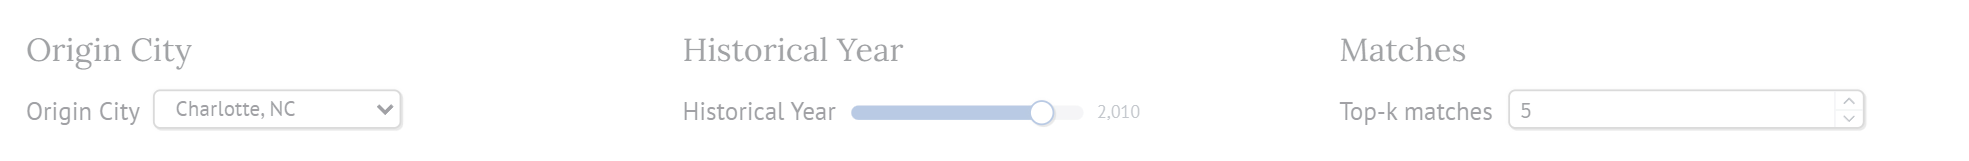

In [ ]:
"""Cell 4 - UI controls: city, year, k."""
_cities = sorted(df['city'].unique().tolist())
_years  = sorted(df['year'].unique().tolist())
_step4  = 5 if len(_years) > 10 else 1
_def_city = 'Boston, MA' if 'Boston, MA' in _cities else _cities[0]
_def_year = min(1975, _years[-2]) if len(_years) > 1 else _years[0]
city_dd = mo.ui.dropdown(_cities, value=_def_city, label='Origin City')
year_sl = mo.ui.slider(min(_years), max(_years), step=_step4, value=_def_year,
                       label='Historical Year', show_value=True)
k_num   = mo.ui.number(1, 10, value=5, label='Top-k matches')
mo.hstack([
    mo.vstack([mo.md('### Origin City'), city_dd]),
    mo.vstack([mo.md('### Historical Year'), year_sl]),
    mo.vstack([mo.md('### Matches'), k_num]),
], justify='start', gap=2)


In [ ]:
"""Cell 5 - NearestNeighbors: find climate doppelgangers."""
_sel_city = city_dd.value
_sel_year = year_sl.value
_k5       = int(k_num.value)
_qrows = df[(df['city'] == _sel_city) & (df['year'] == _sel_year)]
if _qrows.empty:
    _av5 = df[df['city'] == _sel_city]
    _qrows = _av5.loc[[(_av5['year'] - _sel_year).abs().idxmin()]] if not _av5.empty else _qrows
if not _qrows.empty:
    _qrow = _qrows.iloc[0]
    _qvec = scaler.transform(_qrow[FEATURE_COLS].values.reshape(1, -1))
    _nd5, _ni5 = nn_model.kneighbors(_qvec, n_neighbors=min(_k5 + 3, len(ref_df)))
    _cands5   = ref_df.iloc[_ni5[0]].copy()
    _cands5['distance'] = _nd5[0]
    matches           = _cands5[_cands5['city'] != _sel_city].head(_k5).reset_index(drop=True)
    query_fingerprint = _qrow
else:
    matches           = pd.DataFrame()
    query_fingerprint = pd.Series(dtype=float)
top_match = matches.iloc[0] if not matches.empty else None


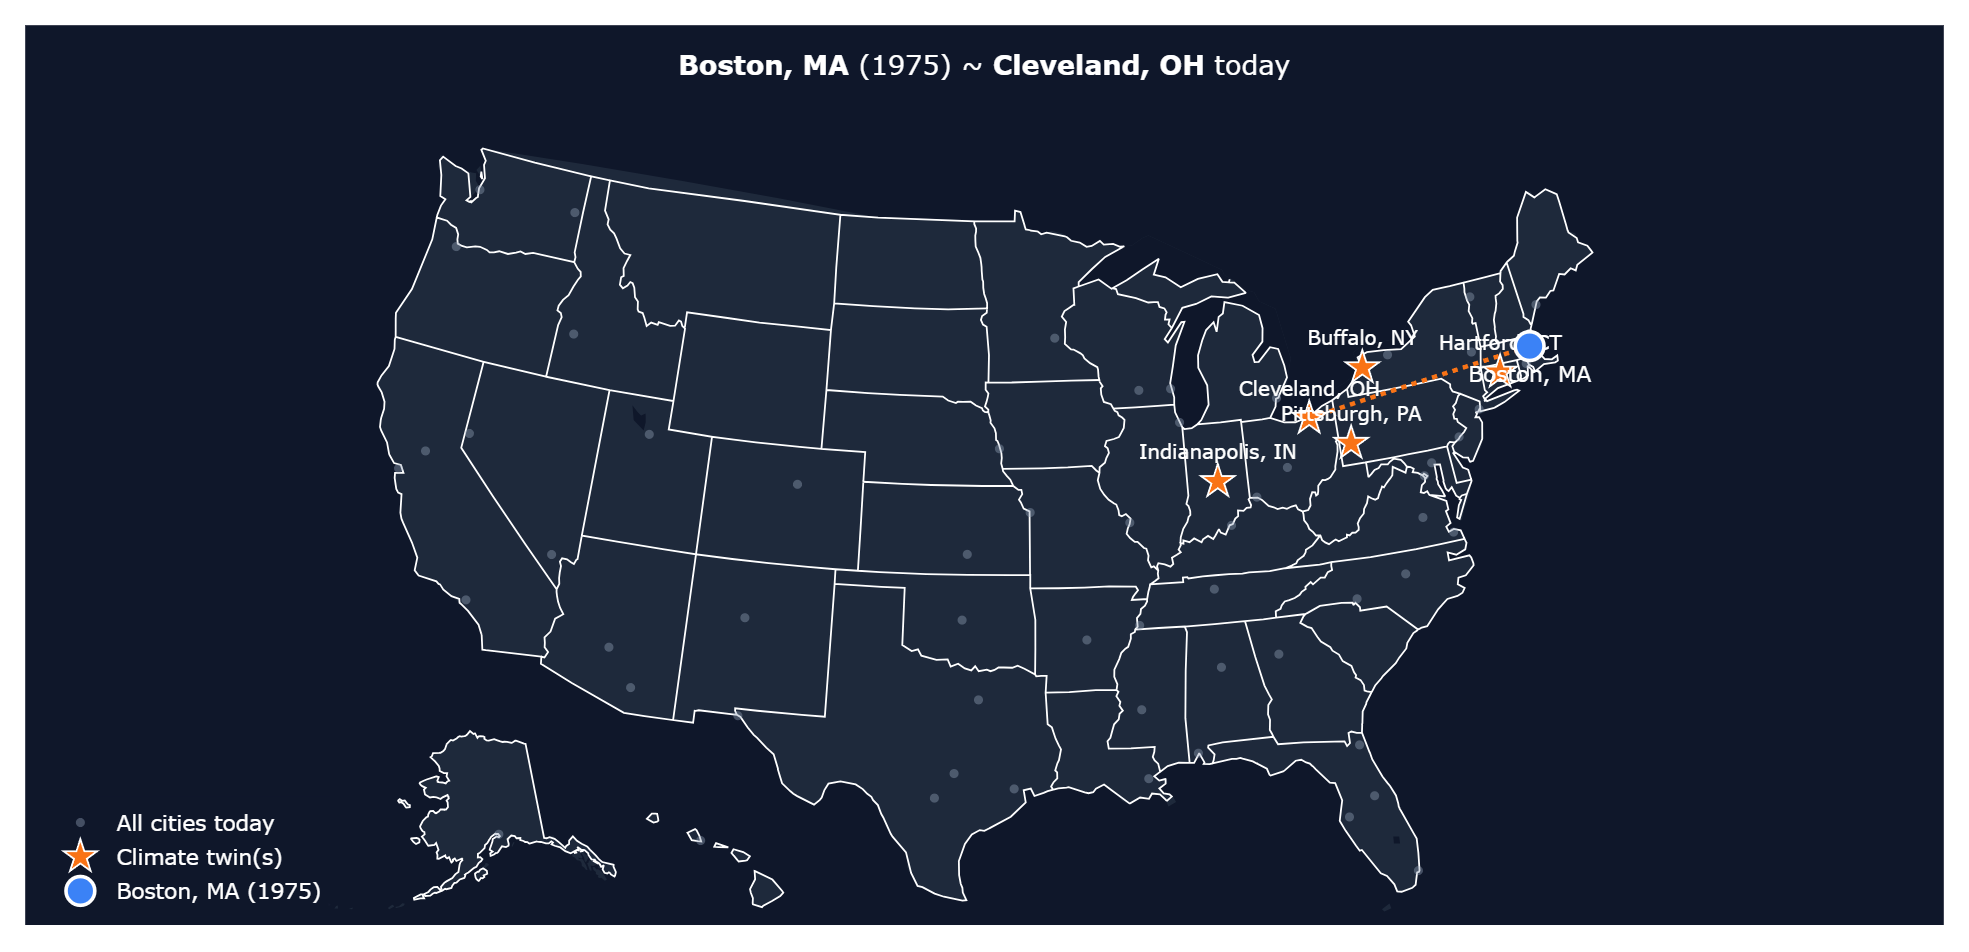

In [ ]:
"""Cell 6 - Plotly map: origin city vs climate twin."""
_fig6 = go.Figure()
if top_match is not None:
    _fig6.add_trace(go.Scattergeo(
        lat=[query_fingerprint['lat'], top_match['lat']],
        lon=[query_fingerprint['lon'], top_match['lon']],
        mode='lines', line=dict(width=2.5, color='#f97316', dash='dot'), showlegend=False))
    _fig6.add_trace(go.Scattergeo(
        lat=ref_df['lat'], lon=ref_df['lon'], mode='markers',
        marker=dict(size=5, color='#94a3b8', opacity=0.4),
        text=ref_df['city'], hovertemplate='%{text}<extra>today</extra>',
        name='All cities today'))
    _fig6.add_trace(go.Scattergeo(
        lat=matches['lat'], lon=matches['lon'], mode='markers+text',
        marker=dict(size=14, color='#f97316', symbol='star', line=dict(width=1, color='white')),
        text=matches['city'], textposition='top center', textfont=dict(size=11, color='white'),
        customdata=matches['distance'].round(3),
        hovertemplate='<b>%{text}</b><br>Dist: %{customdata}<extra>Twin</extra>',
        name='Climate twin(s)'))
    _fig6.add_trace(go.Scattergeo(
        lat=[query_fingerprint['lat']], lon=[query_fingerprint['lon']],
        mode='markers+text',
        marker=dict(size=16, color='#3b82f6', symbol='circle', line=dict(width=2, color='white')),
        text=[city_dd.value], textposition='bottom center', textfont=dict(size=12, color='white'),
        name=f'{city_dd.value} ({year_sl.value})'))
    _t6 = f'<b>{city_dd.value}</b> ({year_sl.value}) ~ <b>{top_match["city"]}</b> today'
else:
    _t6 = 'Select a city and year'
_fig6.update_layout(
    title=dict(text=_t6, x=0.5, font=dict(size=15, color='white')),
    geo=dict(scope='north america', projection_type='albers usa',
             showland=True, landcolor='#1e293b', showlakes=True, lakecolor='#0f172a',
             showcoastlines=True, coastlinecolor='#475569', showframe=False, bgcolor='#0f172a'),
    paper_bgcolor='#0f172a', plot_bgcolor='#0f172a', font=dict(color='white'),
    legend=dict(x=0.01, y=0.01, bgcolor='rgba(15,23,42,0.8)'),
    margin=dict(l=0, r=0, t=55, b=0), height=500)
mo.ui.plotly(_fig6)


In [ ]:
"""Cell 7 - Radar chart: climate fingerprint overlap."""
if top_match is not None:
    _lb7 = ['Mean Temp', 'Precip/100', 'Temp Range', 'Seasonality']
    _ov7 = [query_fingerprint['mean_temp'], query_fingerprint['precip']/100,
            query_fingerprint['temp_range'], query_fingerprint['seasonality']]
    _mv7 = [top_match['mean_temp'], top_match['precip']/100,
            top_match['temp_range'], top_match['seasonality']]
    _th7 = _lb7 + [_lb7[0]]
    _rf7 = go.Figure()
    _rf7.add_trace(go.Scatterpolar(
        r=_ov7 + [_ov7[0]], theta=_th7, fill='toself',
        name=f'{city_dd.value} ({year_sl.value})',
        line=dict(color='#3b82f6', width=2.5), fillcolor='rgba(59,130,246,0.2)'))
    _rf7.add_trace(go.Scatterpolar(
        r=_mv7 + [_mv7[0]], theta=_th7, fill='toself',
        name=f'{top_match["city"]} ({REFERENCE_YEAR})',
        line=dict(color='#f97316', width=2.5), fillcolor='rgba(249,115,22,0.2)'))
    _rf7.update_layout(
        polar=dict(radialaxis=dict(visible=True, gridcolor='#334155', color='#94a3b8'),
                   angularaxis=dict(gridcolor='#334155'), bgcolor='#1e293b'),
        paper_bgcolor='#0f172a', font=dict(color='white', size=12),
        title=dict(text='Climate Fingerprint Overlap', x=0.5),
        legend=dict(x=0.01, y=1.1, bgcolor='rgba(0,0,0,0)'), height=420)
    mo.ui.plotly(_rf7)
else:
    mo.md('*Select a city and year above.*')


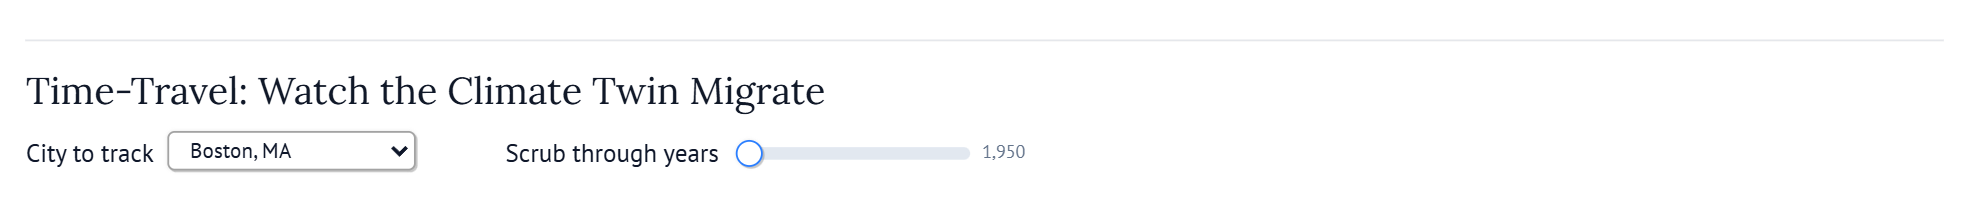

In [ ]:
"""Cell 8 - Time-travel controls."""
_ym8, _yx8 = int(df['year'].min()), int(df['year'].max())
_st8 = 5 if (_yx8 - _ym8) >= 30 else 1
travel_city_dd = mo.ui.dropdown(
    sorted(df['city'].unique().tolist()), value=city_dd.value, label='City to track')
travel_sl = mo.ui.slider(_ym8, _yx8, step=_st8, value=_ym8,
                         label='Scrub through years', show_value=True)
mo.vstack([
    mo.md('---\n## Time-Travel: Watch the Climate Twin Migrate'),
    mo.hstack([travel_city_dd, travel_sl], justify='start', gap=3),
])


In [ ]:
"""Cell 8b - Map reacting to time-travel slider."""
_tc8, _ty8 = travel_city_dd.value, travel_sl.value
_tq8 = df[(df['city'] == _tc8) & (df['year'] == _ty8)]
if _tq8.empty:
    _av8 = df[df['city'] == _tc8]
    _tq8 = _av8.loc[[(_av8['year'] - _ty8).abs().idxmin()]] if not _av8.empty else _tq8
if not _tq8.empty:
    _tv8 = scaler.transform(_tq8.iloc[0][FEATURE_COLS].values.reshape(1, -1))
    _td8, _ti8 = nn_model.kneighbors(_tv8, n_neighbors=min(4, len(ref_df)))
    _tc8c = ref_df.iloc[_ti8[0]].copy()
    _tc8c['dist'] = _td8[0]
    _tm8  = _tc8c[_tc8c['city'] != _tc8].head(1)
    _to8  = _tq8.iloc[0]
    _by8  = int(df[df['city'] == _tc8]['year'].min())
    _br8  = df[(df['city'] == _tc8) & (df['year'] == _by8)]
    _dt8  = round(_to8['mean_temp'] - _br8.iloc[0]['mean_temp'], 1) if not _br8.empty else 0
    _ds8  = f'+{_dt8}' if _dt8 >= 0 else str(_dt8)
    _tf8  = go.Figure()
    _tf8.add_trace(go.Scattergeo(
        lat=ref_df['lat'], lon=ref_df['lon'], mode='markers',
        marker=dict(size=4, color='#475569', opacity=0.4),
        text=ref_df['city'], hovertemplate='%{text}<extra></extra>', showlegend=False))
    if not _tm8.empty:
        _tmr8 = _tm8.iloc[0]
        _tf8.add_trace(go.Scattergeo(
            lat=[_to8['lat'], _tmr8['lat']], lon=[_to8['lon'], _tmr8['lon']],
            mode='lines', line=dict(width=3, color='#f97316', dash='dot'), showlegend=False))
        _tf8.add_trace(go.Scattergeo(
            lat=[_tmr8['lat']], lon=[_tmr8['lon']], mode='markers+text',
            marker=dict(size=15, color='#f97316', symbol='star', line=dict(width=1, color='white')),
            text=[_tmr8['city']], textposition='top center', textfont=dict(size=11, color='white'),
            name=f'Twin: {_tmr8["city"]}'))
    _tf8.add_trace(go.Scattergeo(
        lat=[_to8['lat']], lon=[_to8['lon']], mode='markers+text',
        marker=dict(size=16, color='#3b82f6', line=dict(width=2, color='white')),
        text=[_tc8], textposition='bottom center', textfont=dict(size=12, color='white'),
        name=f'Origin: {_tc8}'))
    _tn8 = _tm8.iloc[0]['city'] if not _tm8.empty else '?'
    _tf8.update_layout(
        title=dict(text=f'<b>{_tc8}</b> in <b>{_ty8}</b>  ~  <b>{_tn8}</b> today  |  dt since {_by8}: {_ds8}C',
                   x=0.5, font=dict(size=14, color='white')),
        geo=dict(scope='north america', projection_type='albers usa',
                 showland=True, landcolor='#1e293b', showlakes=True, lakecolor='#0f172a',
                 showcoastlines=True, coastlinecolor='#475569', showframe=False, bgcolor='#0f172a'),
        paper_bgcolor='#0f172a', font=dict(color='white'),
        legend=dict(x=0.01, y=0.01, bgcolor='rgba(15,23,42,0.8)'),
        margin=dict(l=0, r=0, t=55, b=0), height=460)
    mo.ui.plotly(_tf8)
else:
    mo.md(f'*No data for {_tc8} in {_ty8}.*')


In [ ]:
"""Cell 9 - Auto-generated narrative panel."""
_c9, _yr9 = city_dd.value, year_sl.value
_ym9 = int(df[df['city'] == _c9]['year'].min())
_yx9 = int(df[df['city'] == _c9]['year'].max())
def _st9(city, year):
    r = df[(df['city'] == city) & (df['year'] == year)]
    return round(float(r.iloc[0]['mean_temp']), 1) if not r.empty else None
_tp9 = _st9(_c9, _ym9)
_tc9 = _st9(_c9, _yx9)
_wm9 = f'+{round(_tc9 - _tp9, 1)}C' if (_tc9 and _tp9) else '?'
_tn9 = top_match['city'] if top_match is not None else 'unknown'
if top_match is not None:
    _dl9  = query_fingerprint['lat'] - top_match['lat']
    _do9  = query_fingerprint['lon'] - top_match['lon']
    _dk9  = int(((_dl9**2 + _do9**2)**0.5) * 111)
    _dir9 = 'south' if _dl9 > 1 else ('north' if _dl9 < -1 else 'nearby')
else:
    _dk9, _dir9 = 0, 'nearby'
mo.md(
    f'---\n'
    f'### Climate Doppelganger Report\n\n'
    f'**{_c9}** in **{_yr9}** most closely resembles **{_tn9}** today ({REFERENCE_YEAR}).\n\n'
    f'> These cities are ~**{_dk9} km** apart, yet share nearly identical '
    f'temperature patterns, precipitation, and seasonal swings.\n\n'
    f'**Warming trend for {_c9} ({_ym9} to {_yx9}):**\n'
    f'- {_ym9}: **{_tp9}C** mean annual temperature\n'
    f'- {_yx9}: **{_tc9}C** mean annual temperature\n'
    f'- Total shift: **{_wm9}** over {_yx9 - _ym9} years\n\n'
    f'*As {_c9} warms, its climate migrates {_dir9}ward.*\n\n'
    f'---'
)


<span class="markdown prose dark:prose-invert contents"><hr />
<h3 id="climate-doppelganger-report">Climate Doppelganger Report</h3>
<span class="paragraph"><strong>Boston, MA</strong> in <strong>1975</strong> most closely resembles <strong>Cleveland, OH</strong> today (2020).</span>
<blockquote>
<span class="paragraph">These cities are ~<strong>1183 km</strong> apart, yet share nearly identical temperature patterns, precipitation, and seasonal swings.</span>
</blockquote>
<span class="paragraph"><strong>Warming trend for Boston, MA (1950 to 2020):</strong></span>
<ul>
<li>1950: <strong>9.8C</strong> mean annual temperature</li>
<li>2020: <strong>11.4C</strong> mean annual temperature</li>
<li>Total shift: <strong>+1.6C</strong> over 70 years</li>
</ul>
<span class="paragraph"><em>As Boston, MA warms, its climate migrates nearbyward.</em></span>
<hr /></span>